# Code to make heatmaps using latent representations of data in LLMs!

In [ ]:
## == CUSTOM HELPER FUNCTIONS == ##
import TDA_functions
import heatmap_functions

/home/kim/mitll/TDA_reason-interpet/mitll/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
## == DATASETS == ##
datasets = [["flores", "~/mitll/TDA_reason-interpet/machine_trans_datasets/flores.csv", "sentence_eng_Latn", "sentence_spa_Latn"],
            ["opus-100", "~/mitll/TDA_reason-interpet/machine_trans_datasets/opus.csv", "translation_eng", "translation_spa"]]

## == MODELS == ##
# [0]: Llama, [1]: Qwen, [2]: RoBERTA, [3]: Electra
models = [["Llama 3.1 8B", "meta-llama/Llama-3.1-8B", "Llama", "Encoder"],
          ["Qwen 3 8B", "Qwen/Qwen3-8B", "Qwen", "Encoder"],
          ["RoBERTa", "FacebookAI/roberta-base", "RoBERTa", "Decoder"],
          ["Electra", "google/electra-small-discriminator", "Electra", "Decoder"]]

In [11]:
# ## RUN IF TDA INFO FROM DATASET NOT STORED FOR MODEL!
# for dataset in datasets:
#     get_ling_feat(dataset, num_sen = 800, spa = True, create = True)
#     for model in models:
#         torch.cuda.empty_cache()
#         torch.cuda.ipc_collect()
#         gc.collect()
#         eng_tda, spa_tda = get_top_feat(model, "a", dataset, spa = True, create = True)

In [12]:
# heatmap labels
linguistic_labels = [['Linguistic Features',["num_tokens", "num_types", "avg_word_length", "char_count",
                        "ttr", "cttr", "herdan_c", "simpson_div", "yules_k",
                        "num_content_words", "lexical_density",
                        "avg_polysemy", "num_long_words", "long_word_ratio", "hapax_legomena", "hapax_ratio",
                        "num_stopwords", "stopword_ratio",
                        "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
                        "entropy", "top_word_freq",
                        "unique_bigram_approx"]]
]

tda_labels = [["Topological Features", ['Num_0dim', 'Max_0dim', 'Max_0dim_Minus_Second', 'Mean_0dim', 'betti_curve_0', 'persistence_entropy_0', 'Num_1dim', 'Max_1dim', 'Max_1dim_Minus_Second', 'Mean_1dim', 'betti_curve_1', 'persistence_entropy_1']],
              ["h0 Features", ["Num_0dim", "Max_0dim", "Mean_0dim", "betti_curve_0", "persistence_entropy_0"]],
              ["h1 Features", ["Num_1dim", "Max_1dim", "Mean_1dim", "betti_curve_1", "persistence_entropy_1"]]
]

print("# features: ", len(linguistic_labels[0][1]))

# features:  25


The percent of significant correlations is 0.0 with an average correlation of 0.0


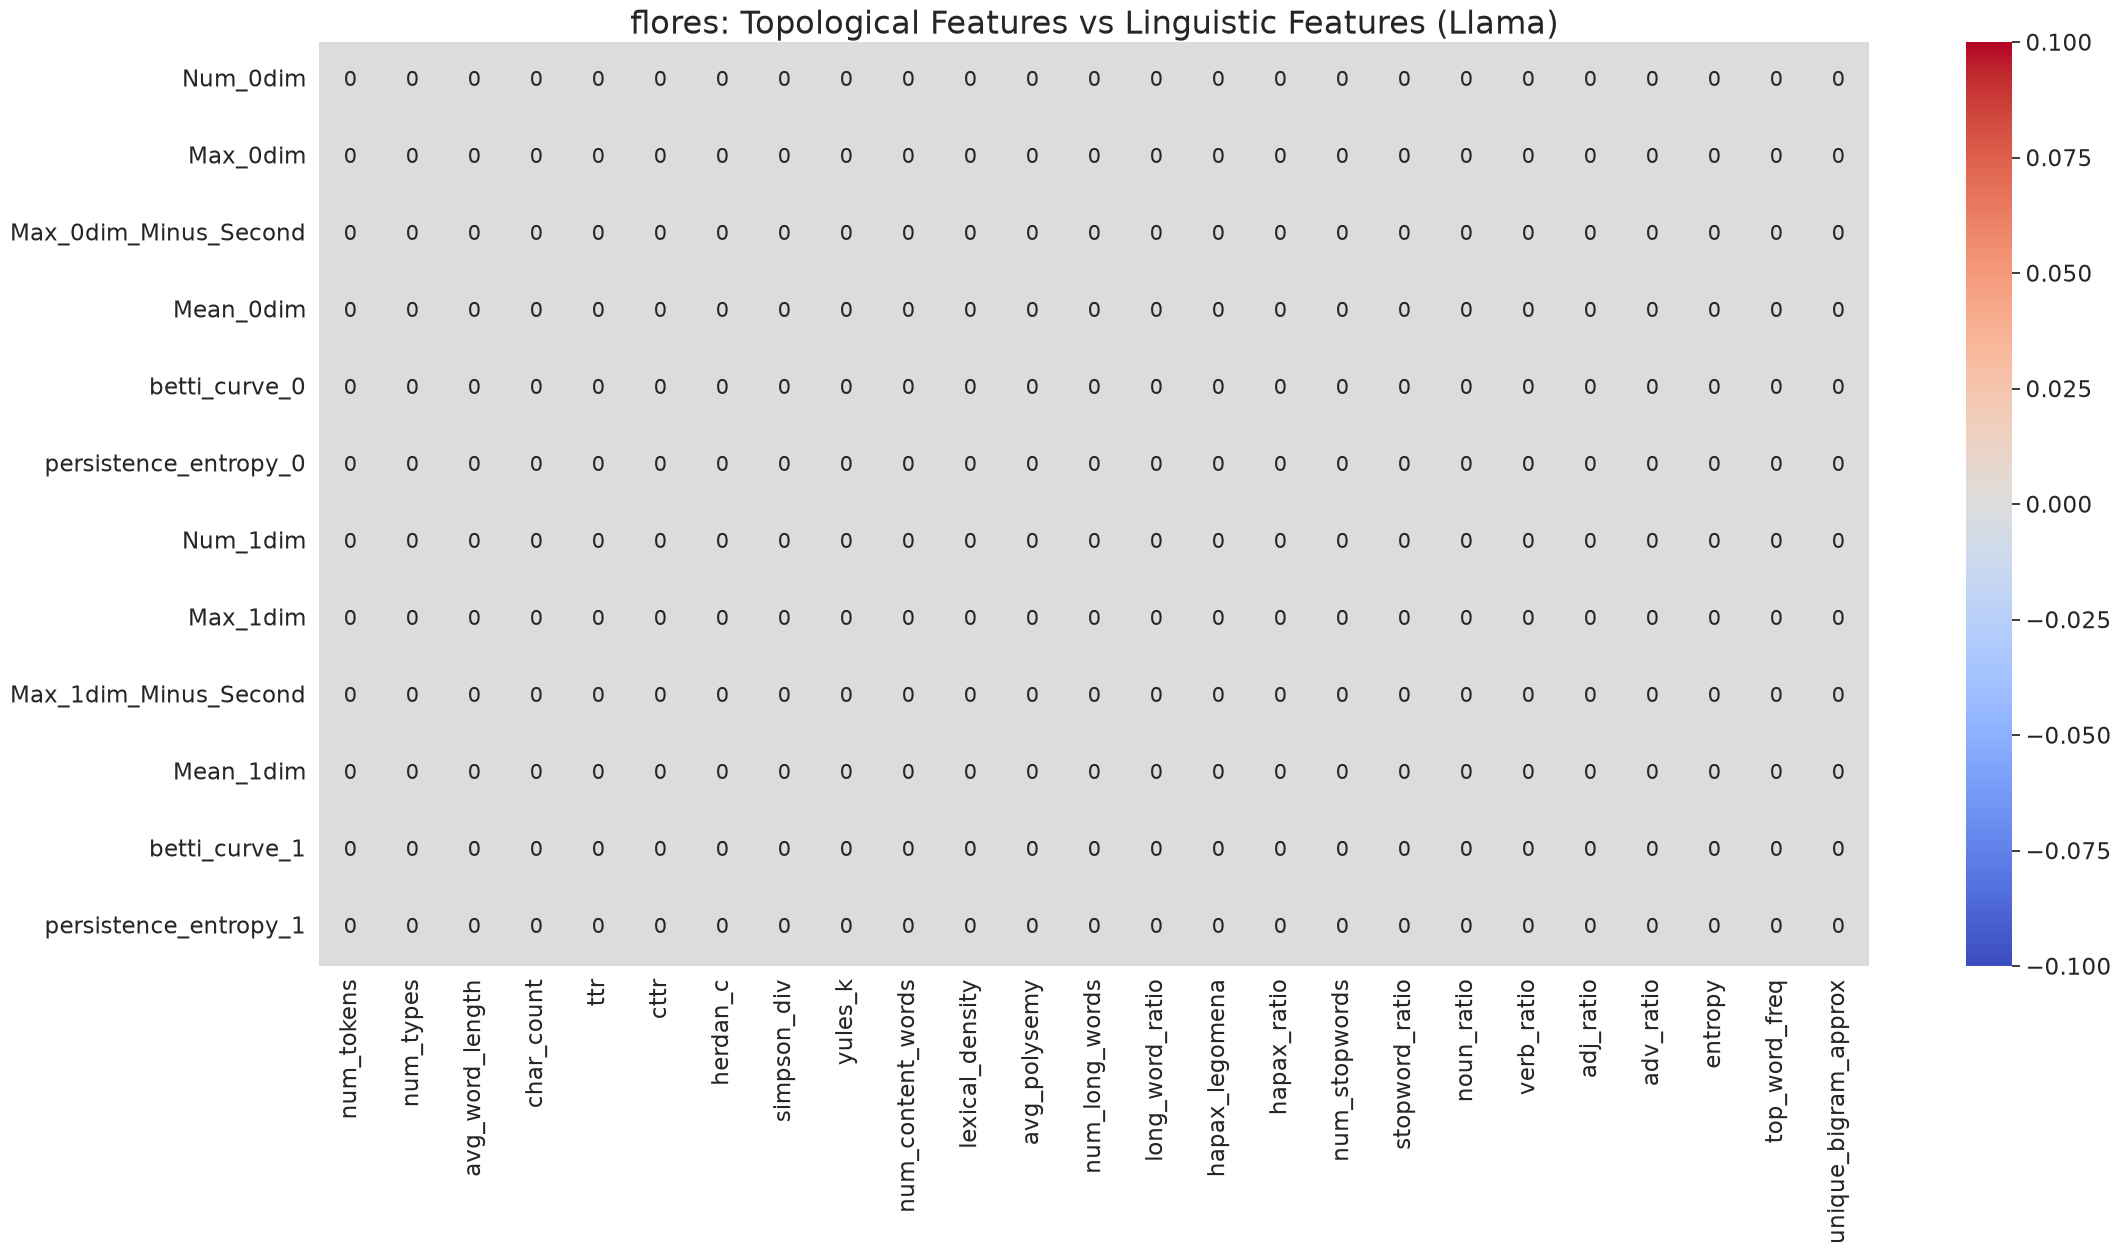

In [32]:
# get heatmap!
make_heatmap(datasets[0], models[0], linguistic_labels[0], tda_labels[0])

In [ ]:
# test pval corr matrix
# choose model and dataset
model_index2 = [1, 2, 5, 6]
data_index2 = [1, 1, 4, 4]
# model_id =  models[8]
# dataset = datasets[3]

# choose linguistic labels :0
tda_label2 = tda_labels[0]

# get heatmap!
for i in range(0,4):
    cor_heat = make_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)
    p_heat = make_pval_heatmap(datasets[data_index2[i]], models[model_index2[i]], linguistic_labels[0], tda_label, extra_label = "_appendix", save = True)


n is: 800
The percent of significant p-values is 0.0 with an average p-value of 1.0


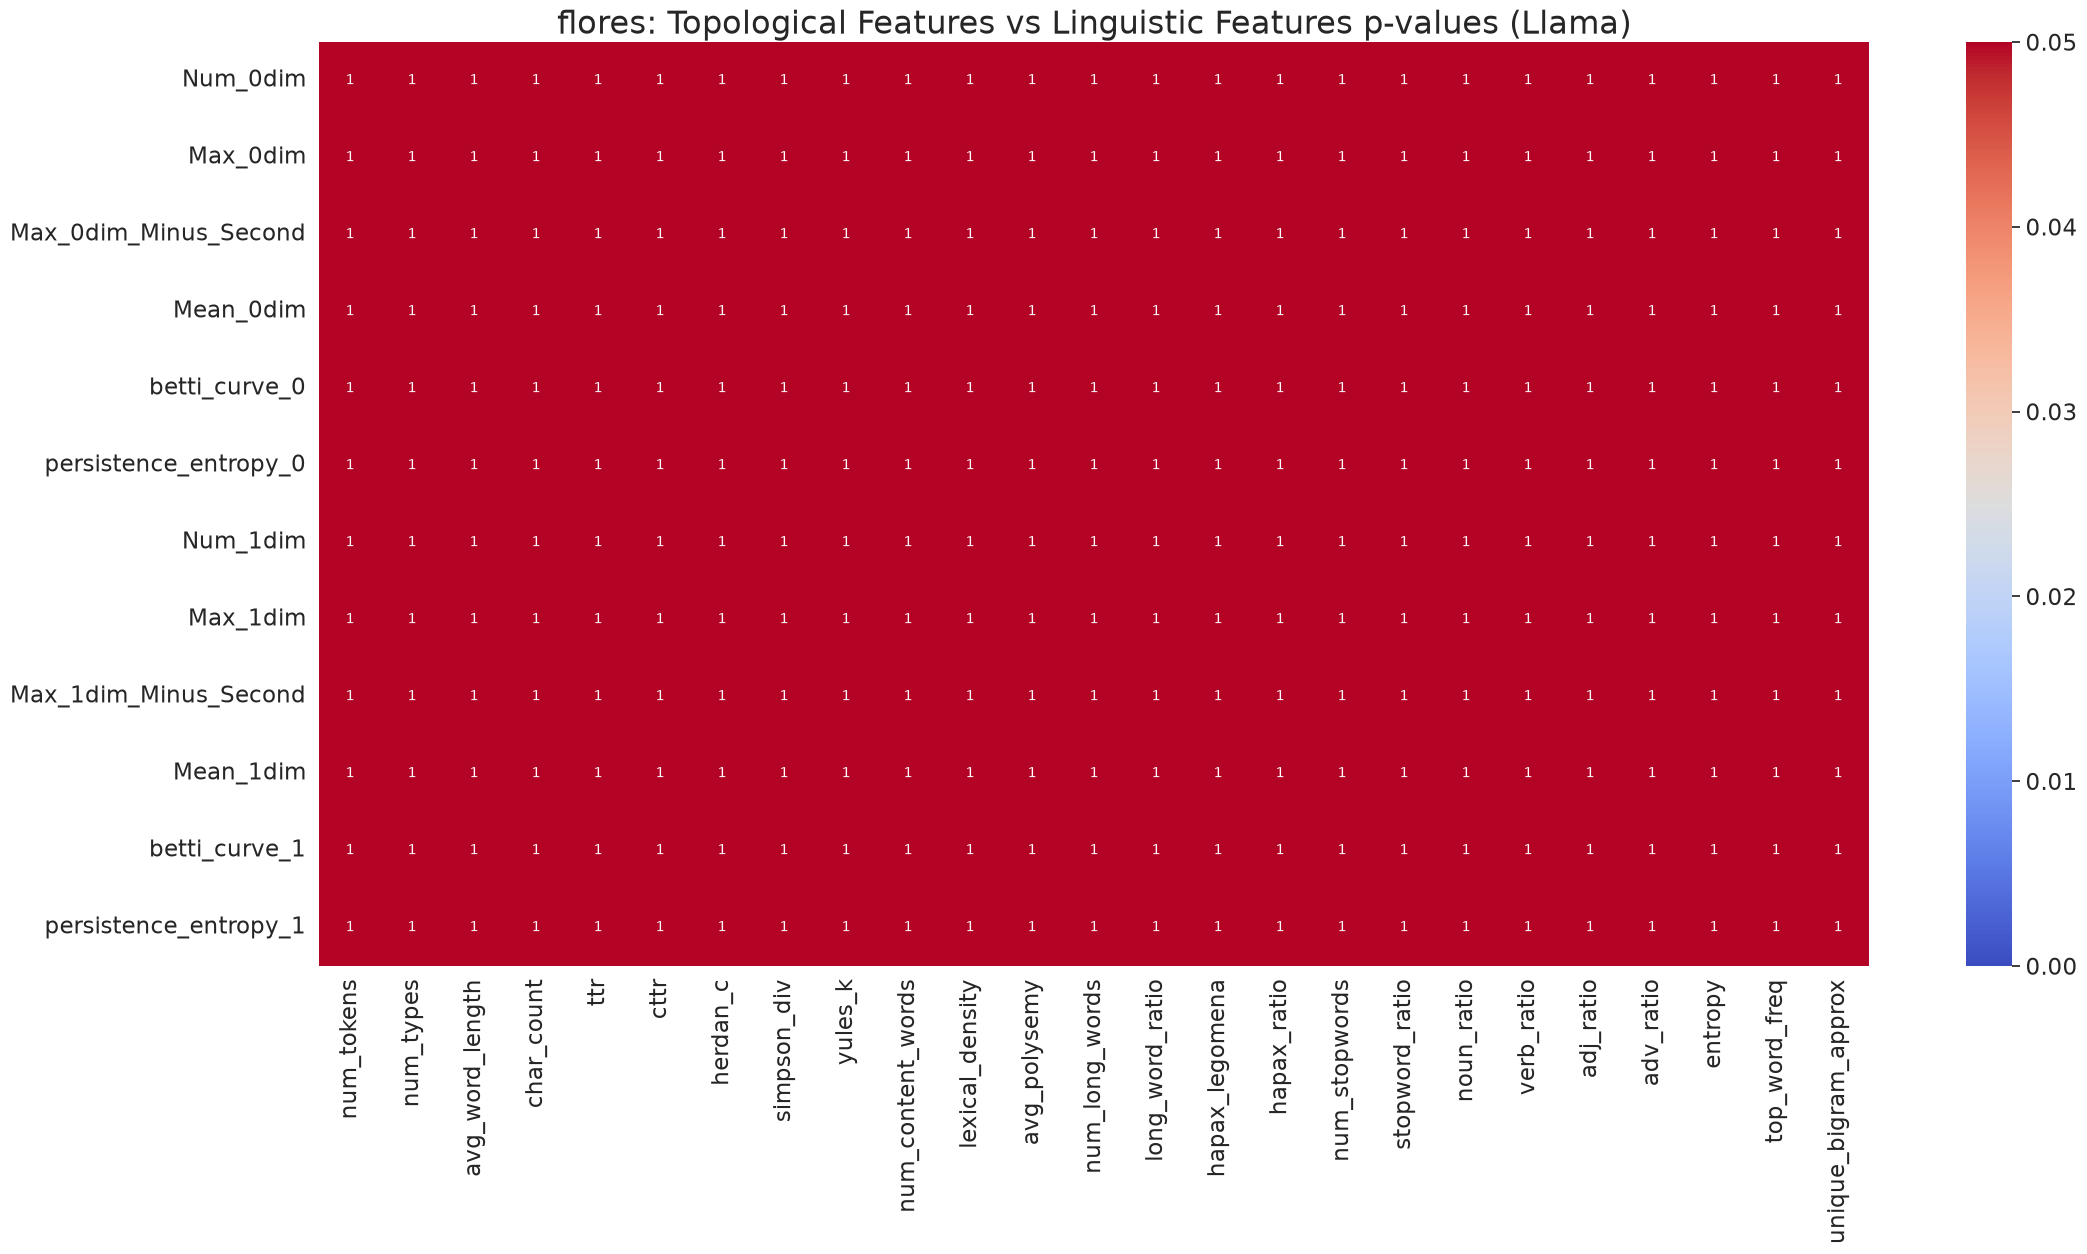

In [49]:
per_sig, avg_pval = make_pval_heatmap(datasets[0], models[0])

# rows = ['Llama'] #, 'Qwen 3','RoBERTa', 'Electra']
# columns = ['flores-200'] #, 'OPUS-100']

# df_per = pd.DataFrame(per_sig)
# df_avg = pd.DataFrame(avg_pval)

# df_per.columns = columns
# df_avg.columns = columns

# df_per = df_per.mean(axis=1)
# df_avg = df_avg.mean(axis=1)

# print(df_per)
# print(df_avg)

In [54]:
# code for table with avg number of words and sentences per data for appendix
for dataset in datasets:
    name, data_csv, eng_label, _ = data_label(dataset)
    df_dataset = pd.read_csv(data_csv)

    # count sentences and words
    df_dataset["sentence_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(sent_tokenize(x)))
    df_dataset["word_count"] = df_dataset[f"{eng_label}"].apply(lambda x: len(word_tokenize(x)))

    # compute averages
    avg_words = df_dataset["word_count"].mean()
    avg_sentences = df_dataset["sentence_count"].mean()

    print(name, ": ")
    summary_table = pd.DataFrame({
        "Metric": ["Average Words", "Average Sentences"],
        "Value": [avg_words, avg_sentences]
    })

    print(summary_table)

flores : 
              Metric     Value
0      Average Words  23.56000
1  Average Sentences   1.10625
opus-100 : 
              Metric   Value
0      Average Words  5.9975
1  Average Sentences  1.0150
